In [1]:
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(gridExtra))
suppressPackageStartupMessages(library(ggpubr))

Sup Fig4A

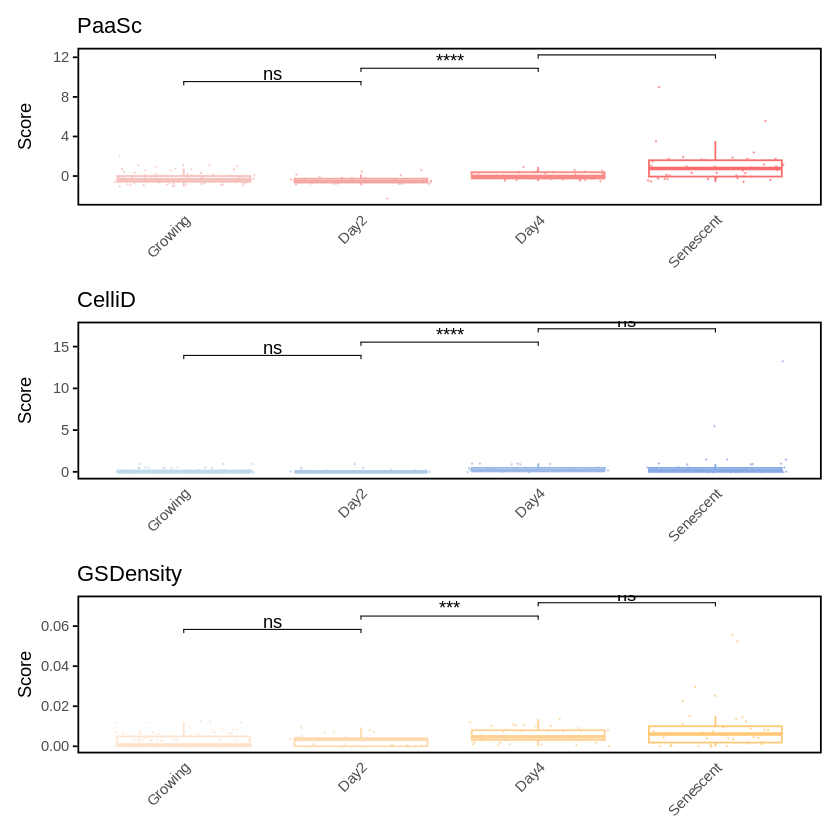

In [2]:
GSE115301_Timecourse_object = readRDS('xxx/PaaSc_Data/Senescence/GSE115301_IMR90_Timecourse.RDS')
GSE115301_Timecourse = read.table('xxx/PaaSc_Data/Senescence/GSE115301_Timecourse_Score.tsv')


levels = c('Growing','Day2','Day4','Senescent')
GSE115301_Timecourse$timecourse = factor(GSE115301_Timecourse_object@meta.data$Time_course, levels = levels)

# Create a function to generate boxplot for each method
generate_boxplot <- function(df, method, colors) {
  ggplot(df, aes(x = timecourse, y = !!sym(method), color = timecourse)) +
          geom_boxplot(outlier.shape = NA) +
          geom_jitter(size=0.1,alpha = 0.5)+
          guides(fill = "none", color = "none")+
          scale_color_manual(values = colors)+
          labs( x = NULL, y = 'Score',title = method) +
          theme_minimal() +
          theme(
                axis.ticks.y = element_line(color = "black"), 
                axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
                panel.background = element_blank(),
                plot.background = element_blank(),
                panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
                panel.grid.major = element_blank(),
                panel.grid.minor = element_blank()  
          )+
  stat_compare_means(
    comparisons =  list(c("Growing", "Day2"), 
                       c("Day2", "Day4"),  c("Day4", "Senescent")), 
      method.args = list(alternative = "less", exact = FALSE), 
    method = "wilcox.test",   
    label = "p.signif")
}
FigPaaSc=generate_boxplot(GSE115301_Timecourse, 'PaaSc', colorRampPalette(c("#F5C2BE", "red"))(8)) 
FigCelliD=generate_boxplot(GSE115301_Timecourse, 'CelliD', colorRampPalette(c('#BFDAE9', 'royalblue'))(8))
FigGSDensity=generate_boxplot(GSE115301_Timecourse, 'GSDensity', colorRampPalette(c('#fee3ce', 'orange'))(8)) 
supFig4A<-(FigPaaSc / FigCelliD / FigGSDensity)
supFig4A

In [3]:
# Create a function to generate boxplot for each method
generate_boxplot <- function(df, method) {
  ggplot(df, aes(x = Group, y = !!sym(method), color = Group)) + 
  
     geom_boxplot(outlier.shape = NA,fill=NA,color='black') + 
     geom_jitter(size=0.001,width = 0.2) +
    guides(fill = "none", color = "none")+
    scale_color_manual(values = c("#D590AA", "#B0CEA6")) +
    scale_x_discrete( labels = c('Growing','Senescent'))+
    labs(x = NULL, y = 'Score', title = method) +
    theme_minimal() + 
    theme(
      aspect.ratio = 1,
         axis.ticks.y = element_line(color = "black"), 
      panel.background = element_blank(),
      plot.background = element_blank(),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank()
    )+
  stat_compare_means(
    comparisons =  list(c("Growing", "Sen")), 
       method.args = list(alternative = "less", exact = FALSE), 
    method = "wilcox.test",   
    label = "p.signif")
}

Sup Fig2B

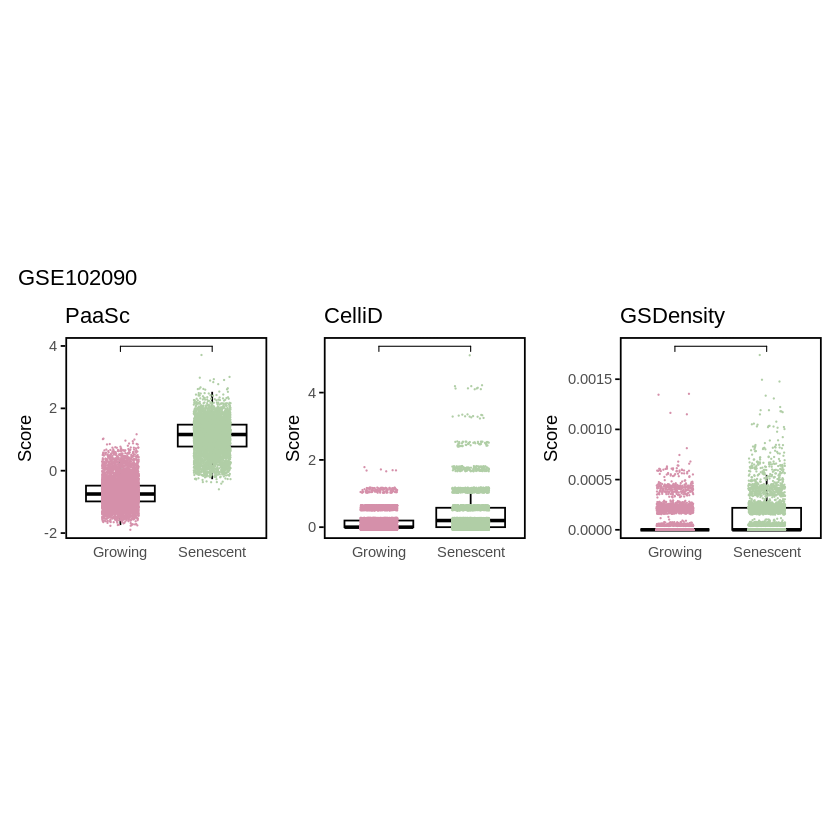

In [4]:
levels =  c('Growing','Sen')
GSE102090 <- read.table('xxx/PaaSc_Data/Senescence/GSE102090_Score.tsv') 
GSE102090$Group = factor(GSE102090$Group, levels = levels)
FigPaaSc=generate_boxplot(GSE102090, 'PaaSc') 
FigCelliD=generate_boxplot(GSE102090, 'CelliD')
FigGSDensity=generate_boxplot(GSE102090, 'GSDensity') 
supFig4B<-(FigPaaSc + FigCelliD + FigGSDensity)+ plot_annotation(title = "GSE102090")
supFig4B

Sup Fig2C

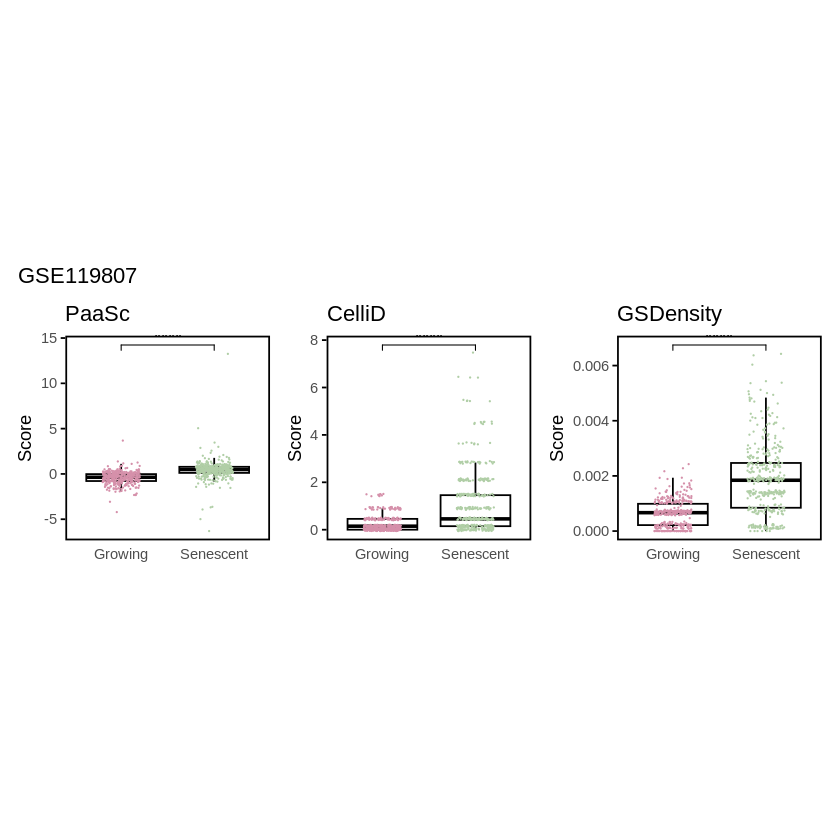

In [5]:
###GSE119807###
GSE119807 <- read.table('xxx/PaaSc_Data/Senescence/GSE119807_Score.tsv') 
GSE119807$Group = factor(GSE119807$Group, levels = levels)
FigPaaSc=generate_boxplot(GSE119807, 'PaaSc') 
FigCelliD=generate_boxplot(GSE119807, 'CelliD')
FigGSDensity=generate_boxplot(GSE119807, 'GSDensity') 
supFig4B<-(FigPaaSc + FigCelliD + FigGSDensity)+ plot_annotation(title = "GSE119807")
supFig4B

supFig2D

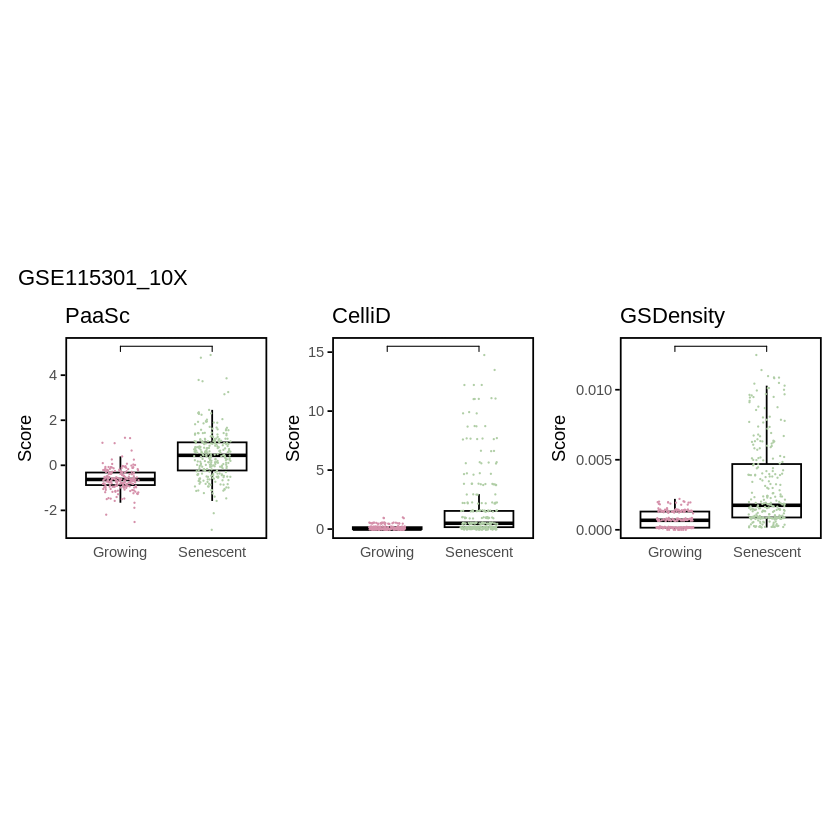

In [6]:
###GSE115301_10X###
GSE115301_10X <- read.table('xxx/liaoxiqi/PaaSc_Data/Senescence/GSE115301_10X_Score.tsv') 
GSE115301_10X$Group = factor(GSE115301_10X$Group, levels = levels)
FigPaaSc=generate_boxplot(GSE115301_10X, 'PaaSc') 
FigCelliD=generate_boxplot(GSE115301_10X, 'CelliD')
FigGSDensity=generate_boxplot(GSE115301_10X, 'GSDensity') 
supFig4D<-(FigPaaSc + FigCelliD + FigGSDensity) + plot_annotation(title = "GSE115301_10X")
supFig4D